            date        BEN        CO        EBE        MXY      NMHC  \
0     2001-01-01   3.878155  0.998400   3.051366   5.846261  0.188304   
1     2001-01-02   2.457269  0.713709   2.279643   3.862333  0.159667   
2     2001-01-03   3.095561  0.871186   2.977262   5.089083  0.209375   
3     2001-01-04   2.917907  0.848846   2.881786   4.923667  0.207322   
4     2001-01-05   5.106791  1.197067   4.597798   7.983583  0.295917   
5     2001-01-06   2.466157  0.756667   2.251726   3.621417  0.134833   
6     2001-01-07   2.747870  0.788221   2.317560   3.617500  0.126667   
7     2001-01-08   5.215488  1.255457   4.482500   6.715083  0.280753   
8     2001-01-09   6.187418  1.341298   5.599701   9.449833  0.277029   
9     2001-01-10   6.978565  1.531298   6.593631  11.300750  0.344083   
10    2001-01-11   4.087721  1.021346   3.923869   7.436750  0.235500   
11    2001-01-12   5.368372  1.290209   4.618631   8.695667  0.209208   
12    2001-01-13   5.157917  1.451410   4.419286   

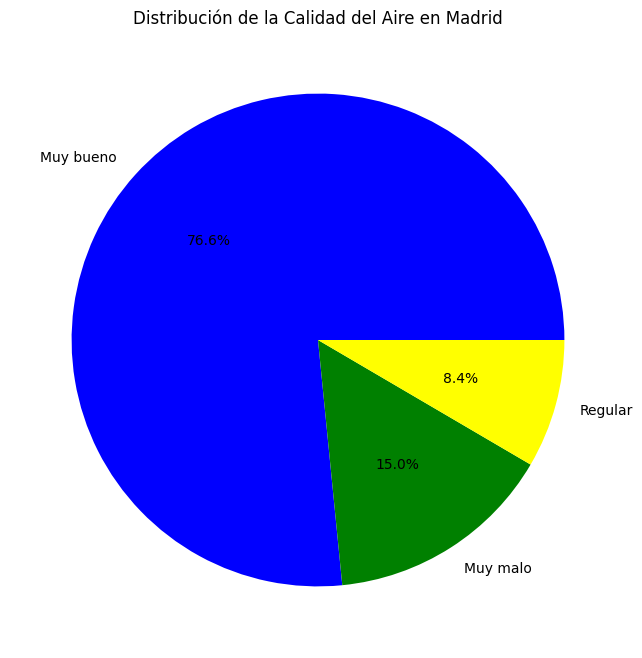

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)  # Muestra todas las filas
pd.set_option('display.max_columns', None)  # Muestra todas las columnas


#Definimos los límites contaminantes:
limitesContaminantes = {
    "PM25": [15, 30, 55, 110],
    "PM10": [25, 50, 90, 180],
    "NO_2": [50, 100, 200, 400],
    "O_3": [60, 120, 180, 240],
    "SO_2": [50, 100, 350, 500]
}


# Ruta de la carpeta donde están los archivos CSV
ruta_carpeta = "./csvs_por_año"

# Obtener la lista de archivos CSV en la carpeta
archivos_csv = [archivo for archivo in os.listdir(ruta_carpeta) if archivo.endswith(".csv")]

# Leer y concatenar todos los archivos en un solo DataFrame
df = pd.concat([pd.read_csv(os.path.join(ruta_carpeta, archivo)) for archivo in archivos_csv], ignore_index=True)

#Eliminar datos redundantes o anómalos.
df = df.drop_duplicates()

# Convertir la columna 'date' a tipo datetime
df["date"] = pd.to_datetime(df["date"])

# Extraer solo la fecha sin las horas
df["date"] = df["date"].dt.date

# Agrupar por fecha y calcular la media de cada contaminante
df_media_diaria = df.groupby("date").mean().reset_index()



def clasificar_calidad(valor, limites):
    """
    Clasifica el valor de contaminación según los rangos de la tabla.
    """
    if valor <= limites[0]:
        return "Muy bueno"
    elif valor <= limites[1]:
        return "Bueno"
    elif valor <= limites[2]:
        return "Regular"
    elif valor <= limites[3]:
        return "Malo"
    else:
        return "Muy malo"
    


# Aplicar la clasificación a cada contaminante
for contaminante, limites in limitesContaminantes.items():
    df_media_diaria[f"categoria_{contaminante}"] = df_media_diaria[contaminante].apply(lambda x: clasificar_calidad(x, limites))

# Determinar la calidad del aire general como la peor categoría entre los contaminantes
df_media_diaria["Calidad_Aire_General"] = df_media_diaria[
    [f"categoria_{c}" for c in limitesContaminantes.keys()]
].max(axis=1)  # Toma la peor categoría


print(df_media_diaria)

df_media_diaria.to_csv("calidad_aire_diaria.csv", index=False)

# Contar la cantidad de días en cada categoría
conteo_calidades = df_media_diaria["Calidad_Aire_General"].value_counts()
print(conteo_calidades)

# Crear el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(conteo_calidades, labels=conteo_calidades.index, autopct="%1.1f%%", colors=["blue", "green", "yellow", "orange", "red"])
plt.title("Distribución de la Calidad del Aire en Madrid")
plt.show()




